In [51]:
# Dependencies and Setup
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import scipy.stats as st
import numpy as np

# Study data files
mouse_metadata_path = "data/Mouse_metadata.csv"
study_results_path = "data/Study_results.csv"

# Read the mouse data and the study results
mouse_metadata = pd.read_csv(mouse_metadata_path)
study_results = pd.read_csv(study_results_path)

# Combine the data into a single DataFrame
mousestudy_df = pd.merge(mouse_metadata, study_results, on="Mouse ID", how="outer")

# Display the data table for preview
mousestudy_df.head()

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,a203,Infubinol,Female,20,23,0,45.000000,0
1,a203,Infubinol,Female,20,23,5,48.508468,0
2,a203,Infubinol,Female,20,23,10,51.852437,1
3,a203,Infubinol,Female,20,23,15,52.777870,1
4,a203,Infubinol,Female,20,23,20,55.173336,1


In [53]:
# Checking the number of mice.
unique = mousestudy_df["Mouse ID"].unique()
len(unique)

249

In [54]:
# Our data should be uniquely identified by Mouse ID and Timepoint
# Get the duplicate mice by ID number that shows up for Mouse ID and Timepoint.
dup_mice = mousestudy_df[mousestudy_df.duplicated(["Mouse ID", "Timepoint"], keep=False)]
dup_mice

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
586,g989,Propriva,Female,21,26,0,45.000000,0
587,g989,Propriva,Female,21,26,0,45.000000,0
588,g989,Propriva,Female,21,26,5,48.786801,0
589,g989,Propriva,Female,21,26,5,47.570392,0
590,g989,Propriva,Female,21,26,10,51.745156,0
591,g989,Propriva,Female,21,26,10,49.880528,0
592,g989,Propriva,Female,21,26,15,51.325852,1
593,g989,Propriva,Female,21,26,15,53.442020,0
594,g989,Propriva,Female,21,26,20,55.326122,1
595,g989,Propriva,Female,21,26,20,54.657650,1


In [102]:
# Create a clean DataFrame by dropping the duplicate mouse by its ID.
# https://stackoverflow.com/questions/18172851/deleting-dataframe-row-in-pandas-based-on-column-value
cleaned_df = mousestudy_df[mousestudy_df["Mouse ID"] != "g989"]
cleaned_df

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,a203,Infubinol,Female,20,23,0,45.000000,0
1,a203,Infubinol,Female,20,23,5,48.508468,0
2,a203,Infubinol,Female,20,23,10,51.852437,1
3,a203,Infubinol,Female,20,23,15,52.777870,1
4,a203,Infubinol,Female,20,23,20,55.173336,1
...,...,...,...,...,...,...,...,...
1888,z969,Naftisol,Male,9,30,25,63.145652,2
1889,z969,Naftisol,Male,9,30,30,65.841013,3
1890,z969,Naftisol,Male,9,30,35,69.176246,4
1891,z969,Naftisol,Male,9,30,40,70.314904,4


In [56]:
# Checking the number of mice in the clean DataFrame.
unique_clean = cleaned_df["Mouse ID"].unique()
len(unique_clean)

248

## Summary Statistics

In [57]:
# Generate a summary statistics table of mean, median, variance, standard deviation, and SEM of the tumor volume for each regimen
cleaned_mean = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].mean()
cleaned_median = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].median()
cleaned_variance = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].var()
cleaned_std = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].std()
cleaned_sem = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].sem()
# Use groupby and summary statistical methods to calculate the following properties of each drug regimen:
# mean, median, variance, standard deviation, and SEM of the tumor volume.
# Assemble the resulting series into a single summary DataFrame.
summary_df = pd.DataFrame()
summary_df["Tumor Volume Mean"] = cleaned_mean
summary_df["Tumor Volume Median"] = cleaned_median
summary_df["Tumor Volume Varaince"] = cleaned_variance
summary_df["Tumor Volume Standard Deviation"] = cleaned_std
summary_df["Tumor Volume SEM"] = cleaned_sem

summary_df

,Tumor Volume Mean,Tumor Volume Median,Tumor Volume Varaince,Tumor Volume Standard Deviation,Tumor Volume SEM
Drug Regimen,,,,,
Capomulin,40.675741,41.557809,24.947764,4.994774,0.329346
Ceftamin,52.591172,51.776157,39.290177,6.268188,0.469821
Infubinol,52.884795,51.820584,43.128684,6.567243,0.492236
Ketapril,55.235638,53.698743,68.553577,8.279709,0.603860
Naftisol,54.331565,52.509285,66.173479,8.134708,0.596466
Placebo,54.033581,52.288934,61.168083,7.821003,0.581331
Propriva,52.320930,50.446266,43.852013,6.622085,0.544332
Ramicane,40.216745,40.673236,23.486704,4.846308,0.320955
Stelasyn,54.233149,52.431737,59.450562,7.710419,0.573111


## Bar and Pie Charts

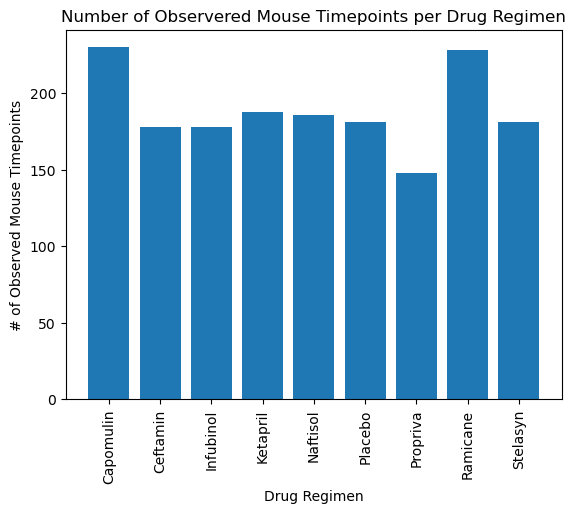

In [58]:
# Generate a bar plot showing the total number of rows (Mouse ID/Timepoints) for each drug regimen using pyplot.
#Drug Count = len(cleaned_df[cleaned_df["Drug Regimen"] == "Drug Name"])
Ca = len(cleaned_df[cleaned_df["Drug Regimen"] == "Capomulin"])
Ce = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ceftamin"])
I = len(cleaned_df[cleaned_df["Drug Regimen"] == "Infubinol"])
K = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ketapril"])
N = len(cleaned_df[cleaned_df["Drug Regimen"] == "Naftisol"])
Pl = len(cleaned_df[cleaned_df["Drug Regimen"] == "Placebo"])
Pr = len(cleaned_df[cleaned_df["Drug Regimen"] == "Propriva"])
R = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ramicane"])
S = len(cleaned_df[cleaned_df["Drug Regimen"] == "Stelasyn"])

x_data = ["Capomulin", "Ceftamin", "Infubinol", "Ketapril", "Naftisol", "Placebo", "Propriva", "Ramicane", "Stelasyn"]
y_data = [Ca, Ce, I, K, N, Pl, Pr, R, S]

plt.bar(x_data, y_data)
plt.xlabel("Drug Regimen")
plt.xticks(rotation=90)
plt.ylabel("# of Observed Mouse Timepoints")
plt.title("Number of Observered Mouse Timepoints per Drug Regimen")
plt.show()

<BarContainer object of 9 artists>

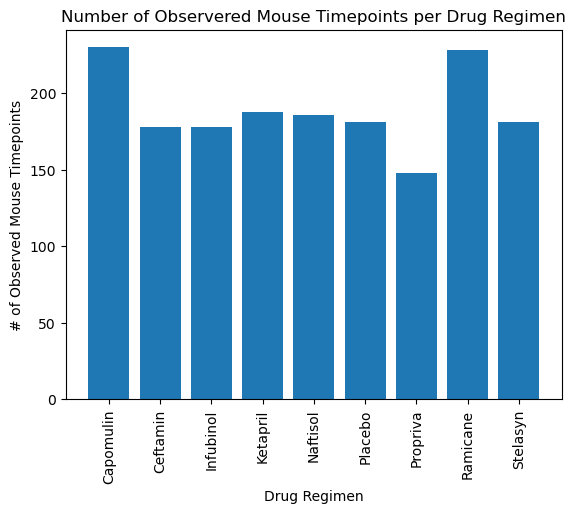

In [59]:
# Generate a bar plot showing the total number of rows (Mouse ID/Timepoints) for each drug regimen using Pandas.
cleaned_df[cleaned_df.groupby(["Drug Regimen"]).sum()].plot(legend=False, rot=90,xlabel="Drug Regimen", ylabel="# of Observed Mouse Timepoints", title="Number of Observered Mouse Timepoints per Drug Regimen").bar(x_data, y_data)

array([<Axes: ylabel='count'>], dtype=object)

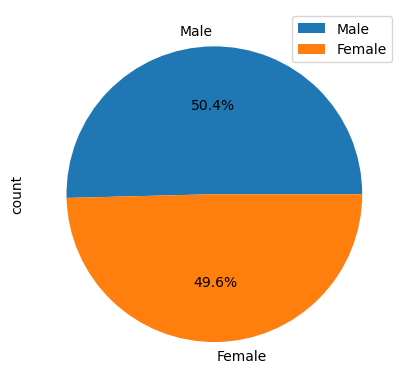

In [60]:
# Generate a pie chart, using Pandas, showing the distribution of unique female versus male mice used in the study

# Get the unique mice with their gender
male = len(cleaned_df[cleaned_df["Sex"] == "Male"]["Mouse ID"].unique())
female = len(cleaned_df[cleaned_df["Sex"] == "Female"]["Mouse ID"].unique())

# Make the pie chart
unique_mouse_gender_pie_chart_df = pd.DataFrame([male, female], index=["Male", "Female"], columns = ["count"])
unique_mouse_gender_pie_chart_df.plot(kind="pie", subplots=True, autopct="%1.1f%%")

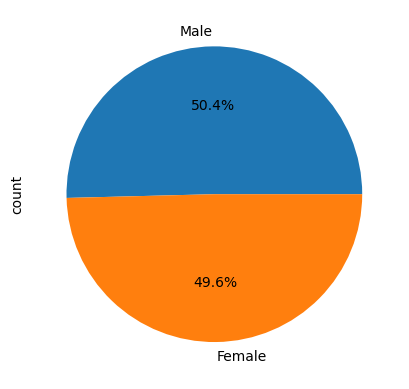

In [61]:
# Generate a pie chart, using pyplot, showing the distribution of unique female versus male mice used in the study

# Get the unique mice with their gender
data = [male, female]
labels= ["Male", "Female"]

# Make the pie chart
plt.pie(data, autopct="%1.1f%%", labels=labels)
plt.ylabel("count")
plt.show()


## Quartiles, Outliers and Boxplots

In [97]:
# Calculate the final tumor volume of each mouse across four of the treatment regimens:  
# Capomulin, Ramicane, Infubinol, and Ceftamin

# Start by getting the last (greatest) timepoint for each mouse
last_timepoints = cleaned_df.groupby("Drug Regimen")["Timepoint"].max()

# Subset the columns from cleaned_df
four_drugs = cleaned_df.loc[(cleaned_df["Drug Regimen"]== "Capomulin")|
                          (cleaned_df["Drug Regimen"]== "Ramicane")|
                          (cleaned_df["Drug Regimen"]== "Infubinol")|
                          (cleaned_df["Drug Regimen"]== "Ceftamin"), :]
# Now merge on the specified keys
four_drugs_final = pd.merge(four_drugs, last_timepoints, on=["Drug Regimen", "Timepoint"], how="left")
four_drugs_final

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,a203,Infubinol,Female,20,23,45,67.973419,2
1,a251,Infubinol,Female,21,25,45,65.525743,1
2,a275,Ceftamin,Female,20,28,45,62.999356,3
3,a411,Ramicane,Male,3,22,45,38.407618,1
4,a444,Ramicane,Female,10,25,45,43.047543,0
...,...,...,...,...,...,...,...,...
58,y769,Ceftamin,Female,6,27,45,68.594745,4
59,y793,Capomulin,Male,17,17,45,31.896238,2
60,y865,Ceftamin,Male,23,26,45,64.729837,3
61,z578,Ramicane,Male,11,16,45,30.638696,0


In [171]:
# Put treatments into a list for for loop (and later for plot labels)
four_treatments = ["Capomulin", "Ramicane", "Infubinol", "Ceftamin"]

# Create empty list to fill with tumor vol data (for plotting)tumor
cap_vol_data = []
ram_vol_data = []
inf_vol_data = []
cef_vol_data = []

# Calculate the IQR and quantitatively determine if there are any potential outliers.

# Locate the rows which contain mice on each drug and get the tumour volumes
    
for index, row in cleaned_df.iterrows():
    if row["Drug Regimen"] == four_treatments[0]:
        cap_vol_data.append(row['Tumor Volume (mm3)'])
    if row["Drug Regimen"] == four_treatments[1]:
        ram_vol_data.append(row['Tumor Volume (mm3)'])
    if row["Drug Regimen"] == four_treatments[2]:
        inf_vol_data.append(row['Tumor Volume (mm3)'])
    if row["Drug Regimen"] == four_treatments[3]:
        cef_vol_data.append(row['Tumor Volume (mm3)'])  
    
    
# add subset
subset_df = cleaned_df[["Mouse ID", "Timepoint", "Tumor Volume (mm3)"]]

# Determine outliers using upper and lower bounds

four_treatments_dict = {
    'Capomulin': cap_vol_data,
    'Ramicane': ram_vol_data,
    'Infubinol': inf_vol_data,
    'Ceftamin': cef_vol_data
}

outlier_series = []

for treatment in four_treatments_dict:
    treatment_series = pd.Series(four_treatments_dict[treatment])

    quartiles = treatment_series.quantile([.25,.5,.75])
    lowerq = quartiles[0.25]
    upperq = quartiles[0.75]

    iqr = upperq-lowerq

    lower_bound = lowerq - (1.5*iqr)
    upper_bound = upperq + (1.5*iqr)

    for value in treatment_series:
        if value > upper_bound  or value < lower_bound:
            outlier_series.append(value)
        else:
            continue
            
    print(f"{treatment}'s potential outliers: {outlier_series}")
    outlier_series = []

Capomulin's potential outliers: [25.47214326, 23.34359787]
Ramicane's potential outliers: [22.05012627]
Infubinol's potential outliers: []
Ceftamin's potential outliers: []


/var/folders/3l/qnm5hprx4z76qvd5ygknmsvr0000gn/T/ipykernel_38702/309111419.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(four_treatments_dict.keys())


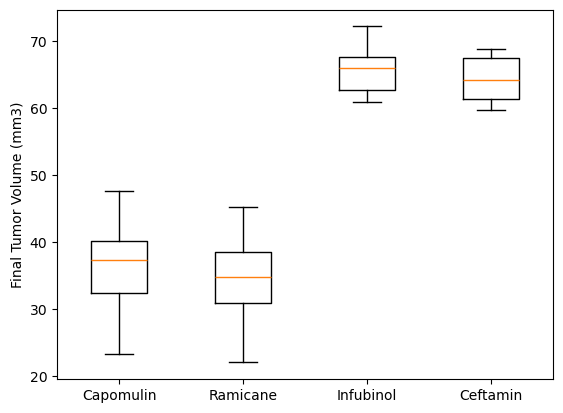

In [174]:
fig, ax = plt.subplots()

four_treatments_dict = {
    'Capomulin': cap_vol_data,
    'Ramicane': ram_vol_data,
    'Infubinol': inf_vol_data,
    'Ceftamin': cef_vol_data
}

ax.set_xticklabels(four_treatments_dict.keys())
ax.set_ylabel('Final Tumor Volume (mm3)')
ax.boxplot(box_plots_dict.values())

plt.show()

## Line and Scatter Plot

Text(0.5, 1.0, "Tumor Volume vs. Time for Mouse ID: 'y793' Treated with Capomulin")

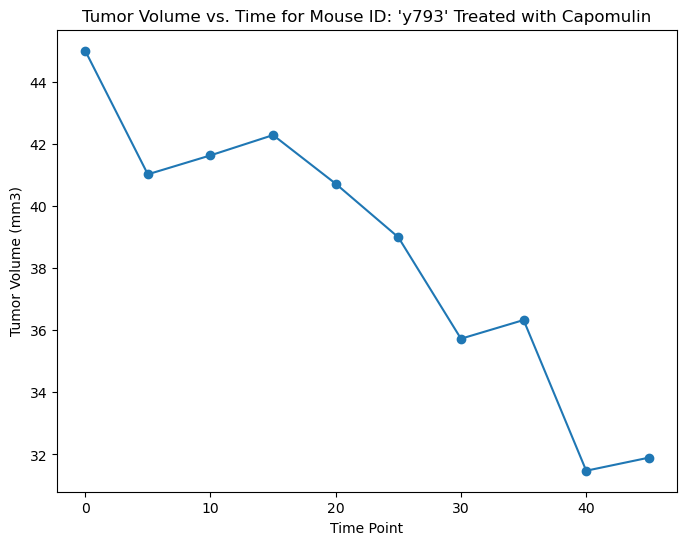

In [219]:
# Generate a line plot of tumor volume vs. time point for a single mouse treated with Capomuli
single_mouse_id = "y793"

filtered_df = cleaned_df[(cleaned_df["Drug Regimen"] == "Capomulin") & (cleaned_df["Mouse ID"] == single_mouse_id)]

x = filtered_df["Timepoint"]
y = filtered_df["Tumor Volume (mm3)"]

plt.figure(figsize=(8,6))
plt.plot(x, y, marker="o", linestyle="-")
plt.xlabel("Time Point")
plt.ylabel("Tumor Volume (mm3)")
plt.title(f"Tumor Volume vs. Time for Mouse ID: '{single_mouse_id}' Treated with Capomulin")

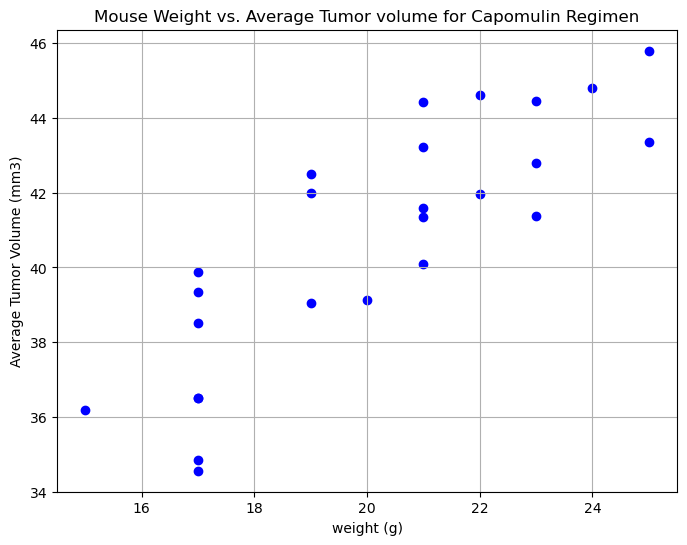

In [41]:
## Generate a scatter plot of mouse weight vs. the average observed tumor volume for the entire Capomulin regin
# Filter the data for Capomulin

sorted_cap_data = mousestudy_df[mousestudy_df["Drug Regimen"] == "Capomulin"]


average_tumor_volume = sorted_cap_data.groupby("Mouse ID").agg(
    AVG_Tumor_Volume=("Tumor Volume (mm3)", "mean"), Weight=("Weight (g)", "mean")).reset_index()
# Generate Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(average_tumor_volume["Weight"], average_tumor_volume["AVG_Tumor_Volume"], color="blue")
plt.title("Mouse Weight vs. Average Tumor volume for Capomulin Regimen")
plt.xlabel("weight (g)")
plt.ylabel("Average Tumor Volume (mm3)")
plt.grid(True)
plt.show()
                                              

## Correlation and Regression

Pearson correlation coefficient: 0.84


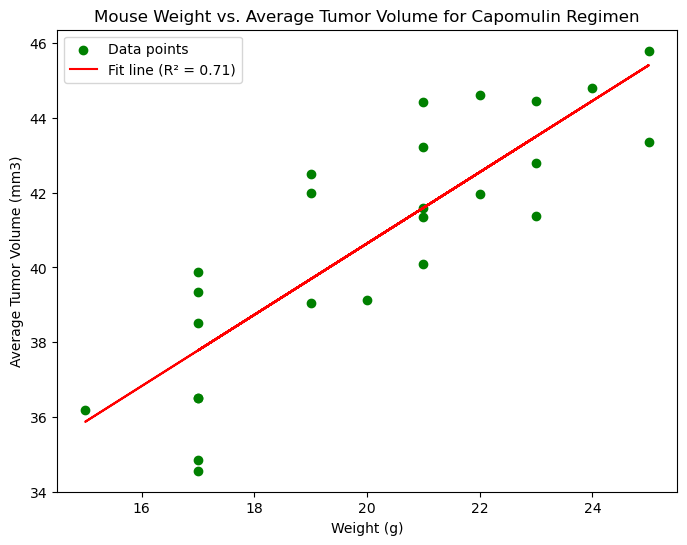

In [159]:
# Calculate the correlation coefficient and a linear regression model
# for mouse weight and average observed tumor volume for the entire Capomulin regimen
# Reference: https://stackoverflow.com/questions/63902183/how-do-i-plot-a-beautiful-scatter-plot-with-linear-regression



# Filter the data for the Capomulin regimen
capomulin_data = mousestudy_df[mousestudy_df["Drug Regimen"] == "Capomulin"]

# Calculate the average tumor volume and weight for each mouse
average_data = capomulin_data.groupby("Mouse ID").agg(
    Avg_Tumor_Volume=("Tumor Volume (mm3)", "mean"),
    Avg_Weight=("Weight (g)", "mean")
).reset_index()

# Compute the Pearson correlation coefficient
correlation = average_data["Avg_Weight"].corr(average_data["Avg_Tumor_Volume"])
print(f"Pearson correlation coefficient: {correlation:.2f}")

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(
    average_data["Avg_Weight"], average_data["Avg_Tumor_Volume"]
)

# Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(average_data["Avg_Weight"], average_data["Avg_Tumor_Volume"], color="green", label="Data points")
plt.plot(
    average_data["Avg_Weight"],
    intercept + slope * average_data["Avg_Weight"],
    color="red",
    label=f"Fit line (R² = {r_value**2:.2f})"
)
plt.title("Mouse Weight vs. Average Tumor Volume for Capomulin Regimen")
plt.xlabel("Weight (g)")
plt.ylabel("Average Tumor Volume (mm3)")
plt.legend()
plt.show()
plt.show()